# Projekt praktyczny (regresja)

## Zbiór danych *Life Expectancy Data.csv* następujące kolumny:
- Country - państwo\
- Status - kraj rozwijający się / rozwinięty\
- Life expectancy - oczekiwana długość życia w latach\
- Adult Mortality - śmiertelność wśród dorosłych, prawdopodobieństwo śmierci w wieku między 15 a 60 lat na 1000 osób\
- infant deaths - śmiertelnośc noworodków w przeliczeniu na 1000 urodzeń\
- Alcohol - konsumpcja alkoholu wśród osób 15+ [w litrach]\
- percentage expenditure - udział wydatków na sektor zdrowia w PKB per capita\
- Hepatitis B - udział zaszczepionych dzieci do 1 roku życia na WZW typu B\
- Measles - liczba odnotowanych przypadków zachorowań na odrę na 1000 mieszkańców\
- BMI\
- under-five deaths - liczba śmierci na 1000 dzieci poniżej 5 roku życia\
- Polio - udział zaszczepionych dzieci do 1 roku życia na Polio\
- Total expenditure - udział wydatków na sektor zdrowia w całości wydatków rządowych\
- Diphtheria - udział zaszczepionych dzieci do 1 roku życia na błonicę i krztusiec\
- HIV/AIDS - śmierci dzieci poniżej 5 roku życia na 1 000 żywych urodzeń spowodowane HIV/AIDS\
- GDP - PKB per capita\
- Population - liczba mieszkańców\
- thinness 1-19 years - rozpowszechnienie chudości w wieku 1 -19 lat\
- thinness 5-9 years - rozpowszechnienie chudości w wieku 5 - 9 lat\
- Income composition of resources - Wskaźnik rozwoju społecznego HDI Human Development Index\
- Schooling - liczba lat nauczania szkolnego\

# Celem projektu jest:
1. przygotowanie i analiza dostarczonych danych
2. budowa i analiza jakości modeli do prognozy oczekiwanej długości życia w latach
3. ocena opracowanych modeli

## Zaimportuj biblioteki

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Wczytaj plik *Life Expectancy Data.csv* oraz wyświetl 5: pierwszych wierszy (0,5 pkt)



In [127]:
df = pd.read_csv("life_e_data.csv", sep=";")
df.head()

,Country,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Albania,Developing,77.8,74.0,0,4.60,364.975229,99.0,0,58.0,...,99.0,6.00,99.0,0.1,3954.227830,28873.0,1.2,1.3,0.762,14.2
2,Algeria,Developing,75.6,19.0,21,NaN,0.000000,95.0,63,59.5,...,95.0,NaN,95.0,0.1,4132.762920,39871528.0,6.0,5.8,0.743,14.4
3,Angola,Developing,52.4,335.0,66,NaN,0.000000,64.0,118,23.3,...,7.0,NaN,64.0,1.9,3695.793748,2785935.0,8.3,8.2,0.531,11.4
4,Antigua and Barbuda,Developing,76.4,13.0,0,NaN,0.000000,99.0,0,47.7,...,86.0,NaN,99.0,0.2,13566.954100,NaN,3.3,3.3,0.784,13.9


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          183 non-null    object 
 1   Status                           183 non-null    object 
 2   Life expectancy                  183 non-null    float64
 3   Adult Mortality                  183 non-null    float64
 4   infant deaths                    183 non-null    int64  
 5   Alcohol                          6 non-null      float64
 6   percentage expenditure           183 non-null    float64
 7   Hepatitis B                      174 non-null    float64
 8   Measles                          183 non-null    int64  
 9   BMI                              181 non-null    float64
 10  under-five deaths                183 non-null    int64  
 11  Polio                            183 non-null    float64
 12  Total expenditure     

# Preprocessing
- wyświetl rozmiar zbioru
- sprawdź ilość w poszczególnych kolumnach NaN-ów
- sprawdź statystyki NaN-ów dla wierszy (m.in. jaka jest mininalna, maxymalna, srednia liczba nanów w wierszu). Jeśli są wiersze, dla których jest >=5 braki usuń je i zresetuj indexy
- jesli występują kolumny z dużą lością NaN-ów usuń je
- wyświetl wiersze od 170 do 175
- pozostałe NaN-y dla zmiennych numerycznych uzupełnij średnią
- oblicz statystyki opisowe
- wyświetl ponownie sumę braków w poszczególnych kolumnach

In [129]:
df.shape

(183, 21)

In [130]:
df.isna().sum() / df.shape[0]

Country                            0.000000
Status                             0.000000
Life expectancy                    0.000000
Adult Mortality                    0.000000
infant deaths                      0.000000
Alcohol                            0.967213
percentage expenditure             0.000000
Hepatitis B                        0.049180
Measles                            0.000000
BMI                                0.010929
under-five deaths                  0.000000
Polio                              0.000000
Total expenditure                  0.989071
Diphtheria                         0.000000
HIV/AIDS                           0.000000
GDP                                0.158470
Population                         0.224044
thinness 1-19 years                0.010929
thinness 5-9 years                 0.010929
Income composition of resources    0.054645
Schooling                          0.054645
dtype: float64

In [131]:
df.drop(columns=["Alcohol", "Total expenditure"], inplace=True)

In [132]:
for col in df.columns:
    if df[col].isna().sum() > 5:
        df[col].dropna(inplace=True)

In [133]:
df.iloc[:, 170:175]

""
0
1
2
3
4
...
178
179
180
181


In [134]:
for col in df.columns:
    if df[col].dtype == "float64" or df[col].dtype == "int64":
        df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_3808378/2226894253.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [135]:
df.isna().sum()

Country                            0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness 1-19 years                0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

# Wizualizacja

Wykonaj wykres rozkładu (histogram i ramka-wąsy) zmiennej *Life expectancy* skategoryzowane w zalezności od statusu kraju.
- Pamiętaj o zasadach sporzadzania wykresów.
- Zinterpretuj wyniki.

/tmp/ipykernel_3808378/1699370738.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df["Status"] == status]["Life expectancy"] for status in df["Status"].unique()], labels=df["Status"].unique())


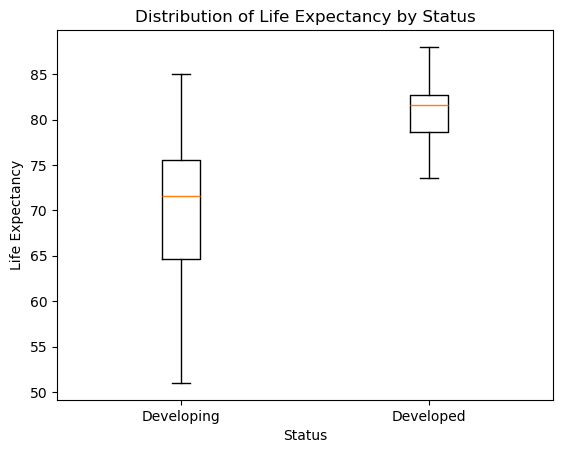

In [136]:
plt.boxplot([df[df["Status"] == status]["Life expectancy"] for status in df["Status"].unique()], labels=df["Status"].unique())
plt.xlabel("Status")
plt.ylabel("Life Expectancy")
plt.title("Distribution of Life Expectancy by Status")
plt.show()

widać że kraje rozwijające się mają mają life expectancy, oraz też większą rozpiętość. W krajach rozwiniętych life expectancy jest wyższe, ale rozpiętość jest większa.

# Korelacja
Wykonaj macierz korelacji dla zmiennych ilościowych. Przedstaw ją graficznie. Z którymi zmiennymi skorelowana jest zmienna *Life expectancy*. Zinterpretuj te korelacje. Dla istotnych korelacji wykonaj wykresy punktowe.

Income composition of resources    0.861431
Adult Mortality                    0.779119
Schooling                          0.776743
HIV/AIDS                           0.608345
Polio                              0.515602
BMI                                0.510951
Diphtheria                         0.500300
thinness 5-9 years                 0.469775
thinness 1-19 years                0.469768
GDP                                0.424769
Hepatitis B                        0.398488
under-five deaths                  0.271921
infant deaths                      0.241290
Measles                            0.074617
percentage expenditure             0.043964
Population                         0.043786
dtype: float64


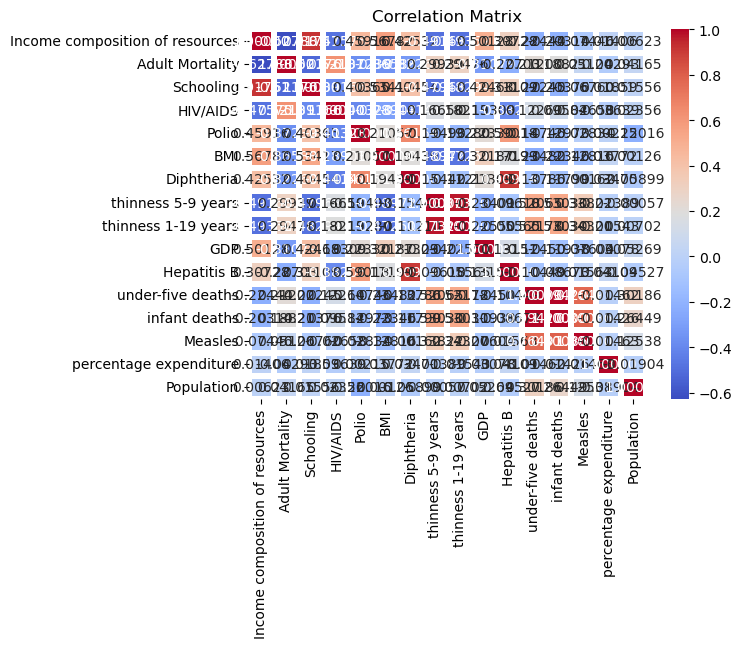

In [137]:
df_num = df.select_dtypes(include=["float64", "int64"])

target = "Life expectancy"
features = df_num.columns[df_num.columns != target]

features_with_life_expectancy_corr = df_num[features].corrwith(df_num[target]).abs().sort_values(ascending=False)
print(features_with_life_expectancy_corr)

sns.heatmap(df_num[features_with_life_expectancy_corr.index].corr(), annot=True, fmt=".5f", cmap="coolwarm", linewidths=3,)
plt.title("Correlation Matrix")
plt.show()

In [138]:
top_features = df_num.corr()["Life expectancy"].abs().sort_values(ascending=False).index[1:10]
print(top_features)

Index(['Income composition of resources', 'Adult Mortality', 'Schooling',
       'HIV/AIDS', 'Polio', 'BMI', 'Diphtheria', 'thinness 5-9 years',
       'thinness 1-19 years'],
      dtype='object')


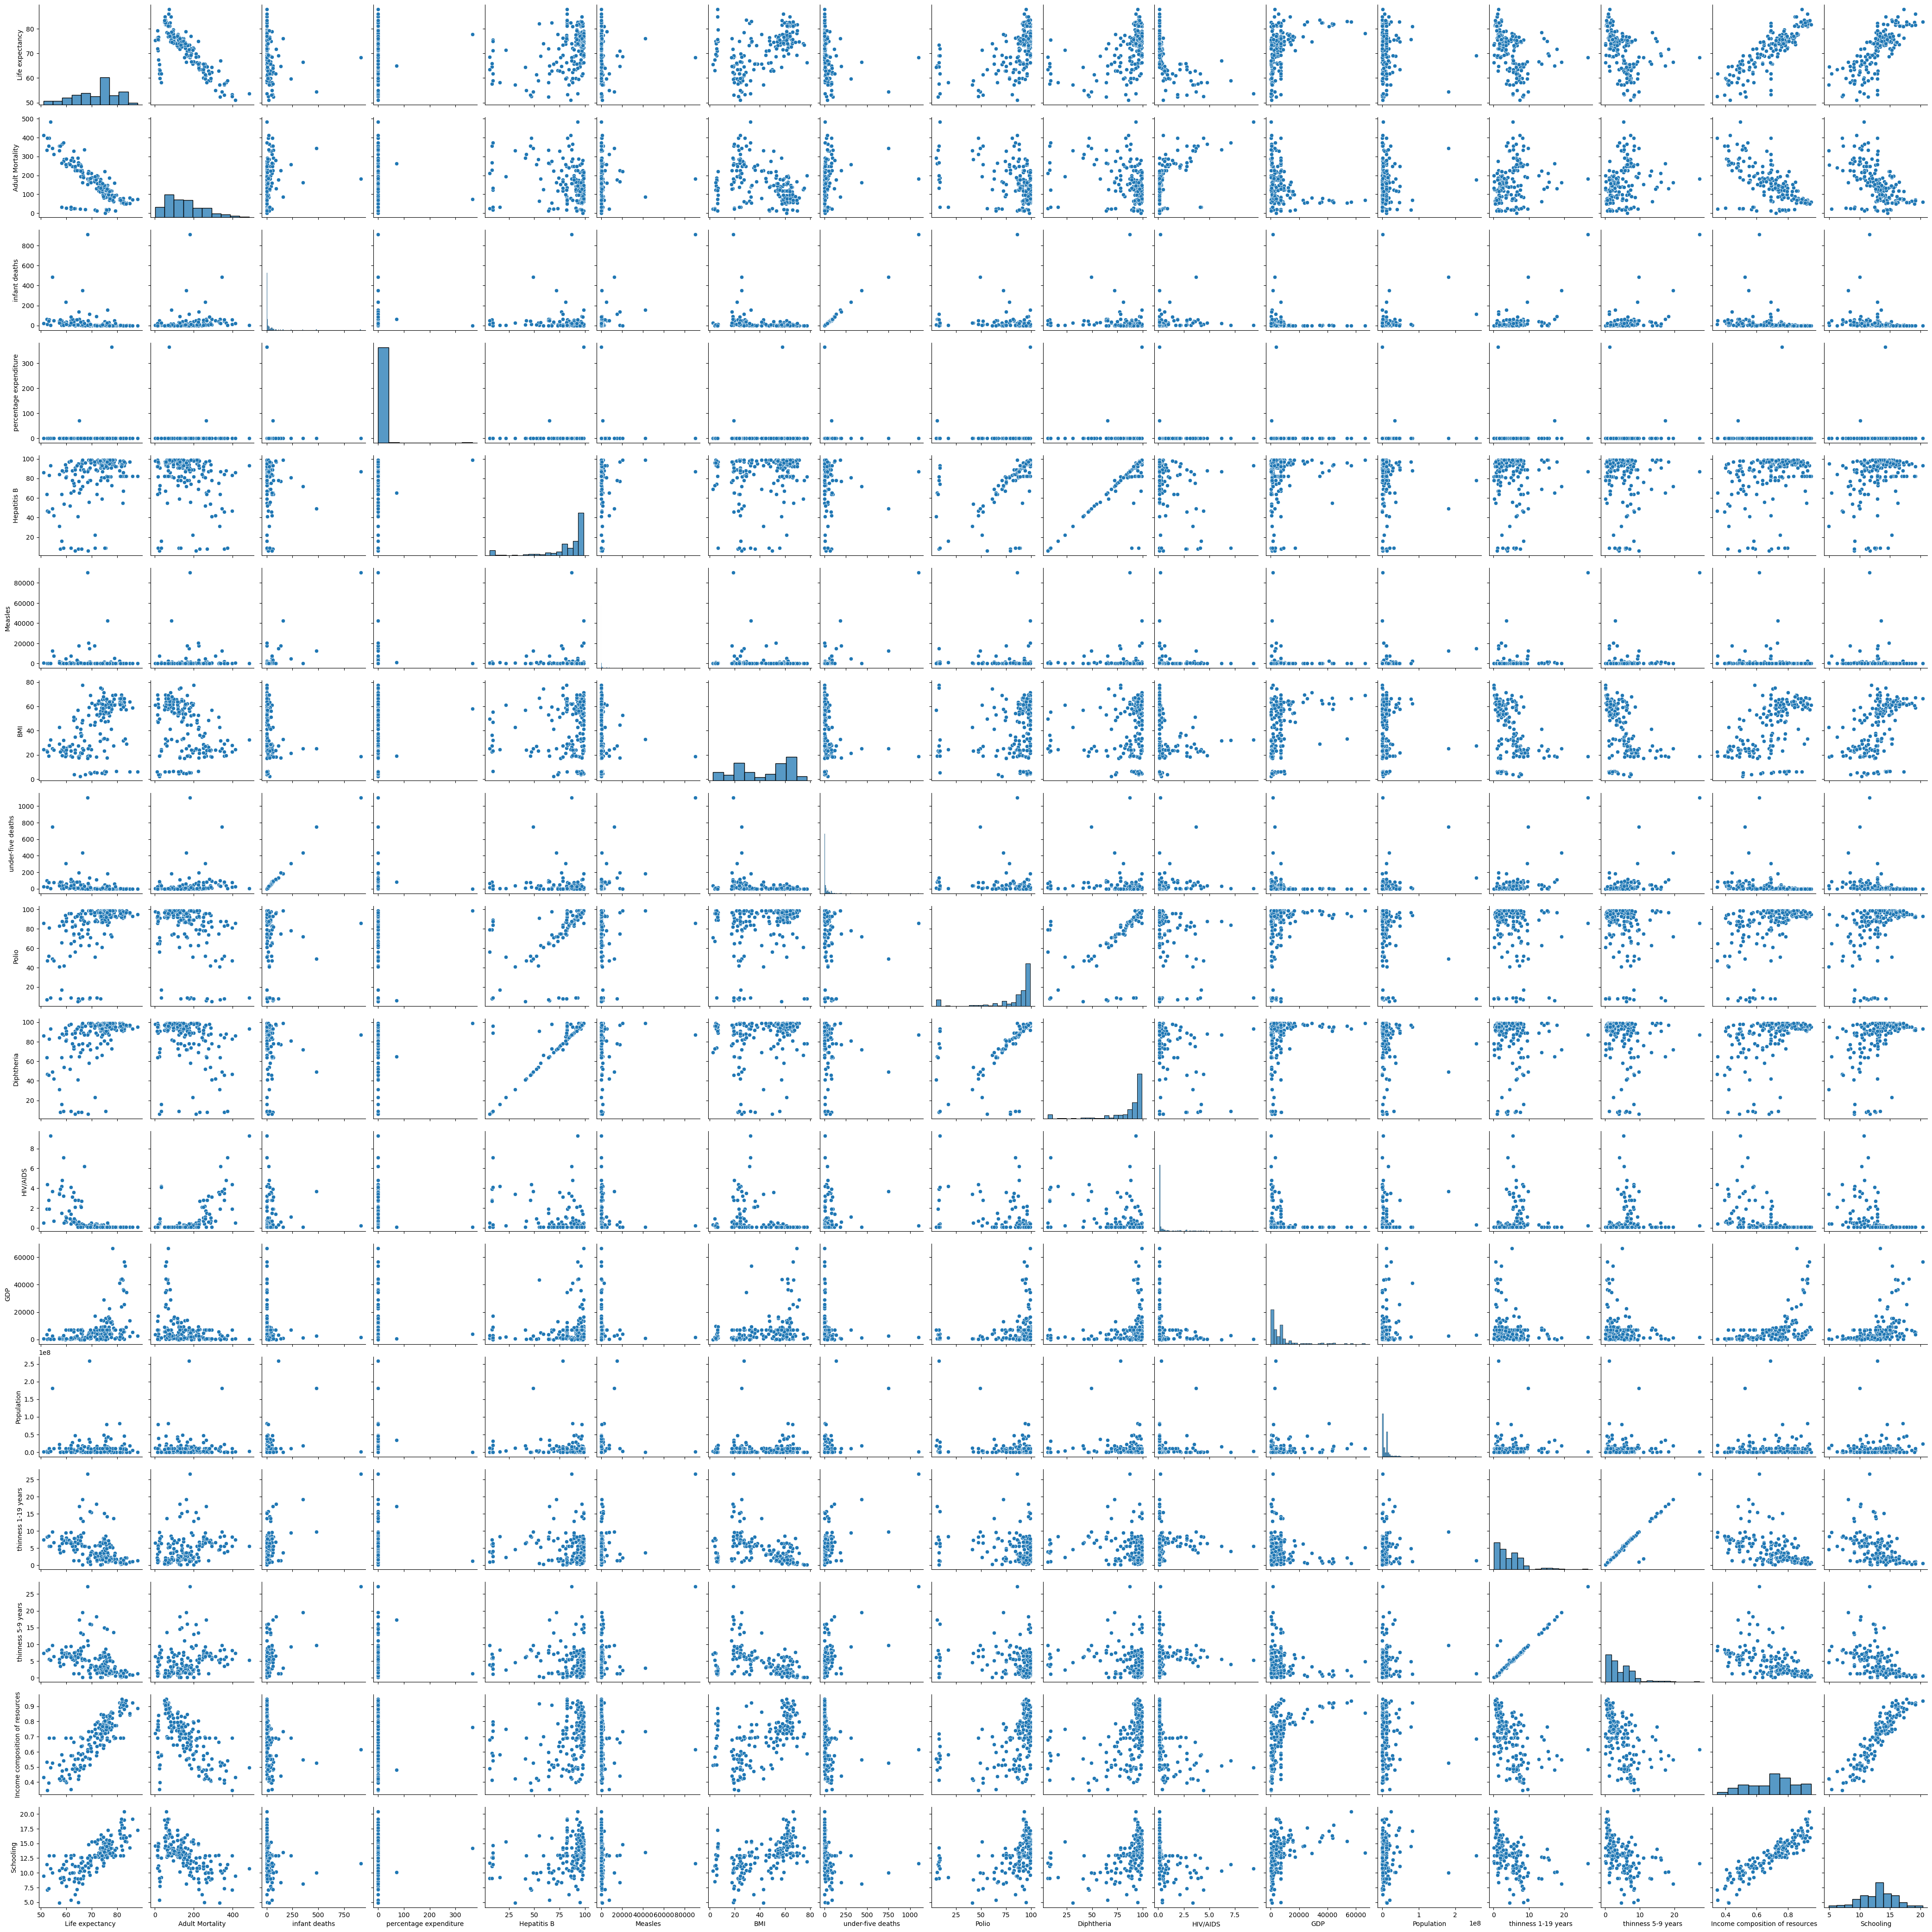

In [139]:
sns.pairplot(df_num)

<Axes: >

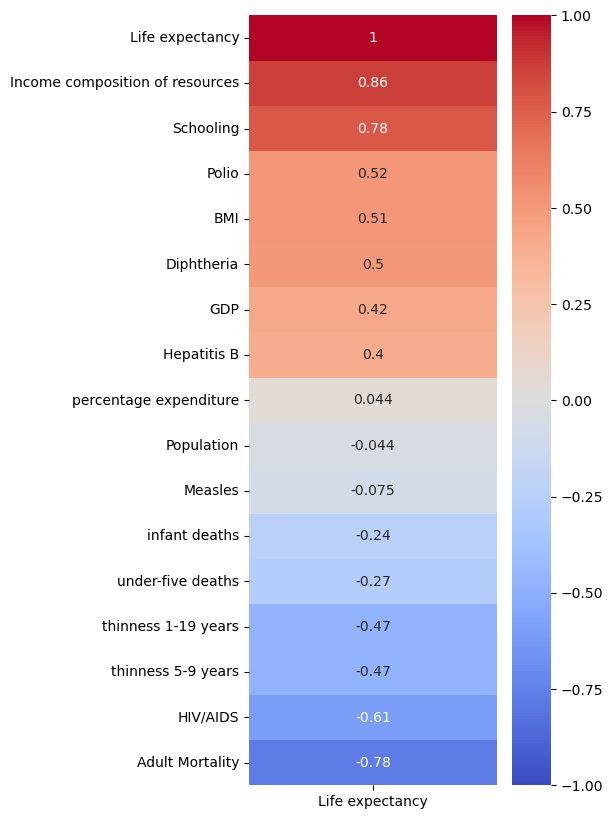

In [140]:
target = "Life expectancy"

corr = (
    df_num.corr(numeric_only=True)[[target]]
    .sort_values(by=target, ascending=False)
)

plt.figure(figsize=(4, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)


# Regresja

## Regresja linowa **jednej** zmiennej
- Zbuduj model regresji liniowej prostej (jednej zmiennej) umozliwijący przewidywanie długości życia w zalezności od liczby lat nauczania szkolnego. Odpowiednio przygotuj X (zmienna objaśniająca) i y (zmienna objasniana). Wyodrębnij zbiór treningowy i testowy.
- Wytrenuj model na zbiorze treningowym.
- Zapisz równanie.
- Wykonaj predykcję dla zbioru treningowego i testowego
- Oblicz metryki (R2, MAE, MSE, RMSE). Oceń jakość modelu (dobrze dopasowany, przetrenowany, niedotrenowany).

In [141]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [142]:

X = df_num["Schooling"].values.reshape(-1, 1)

y = df_num["Life expectancy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [143]:
X

array([[10.1       ],
       [14.2       ],
       [14.4       ],
       [11.4       ],
       [13.9       ],
       [17.3       ],
       [12.7       ],
       [20.4       ],
       [15.9       ],
       [12.7       ],
       [12.6       ],
       [14.5       ],
       [10.2       ],
       [15.3       ],
       [15.6       ],
       [16.6       ],
       [12.8       ],
       [10.7       ],
       [12.5       ],
       [13.8       ],
       [14.2       ],
       [12.6       ],
       [15.2       ],
       [14.9       ],
       [15.        ],
       [ 7.7       ],
       [10.6       ],
       [12.92716763],
       [13.5       ],
       [10.9       ],
       [10.4       ],
       [16.3       ],
       [ 7.1       ],
       [ 7.3       ],
       [16.3       ],
       [13.5       ],
       [13.6       ],
       [11.1       ],
       [11.1       ],
       [14.2       ],
       [15.3       ],
       [13.9       ],
       [14.3       ],
       [12.92716763],
       [12.92716763],
       [12

### Predykcja

In [144]:
pred = model.predict(X_test)

### Ocena modelu

In [145]:
mae1 = mean_absolute_error(y_test, pred)

In [146]:
mse1 = mean_squared_error(y_test, pred)

In [147]:
rmse1 = root_mean_squared_error(y_test, pred)

In [148]:
r1 = model.score(X_test, y_test)
print(f"R2: {r1:.4f}")

R2: 0.5634


myśle że jest git

## Regresja linowa **wielu** zmiennych

- Zbuduj model regresji liniowej prostej (jednej zmiennej) umozliwijący przewidywanie długości życia w zalezności od wskaźnika rozwoju społecznego i liczby lat nauczania szkolnego. Odpowiednio przygotuj X (zmienne objaśniające) i y (zmienna objasniana). Wyodrębnij zbiór treningowy i testowy.
- Zapisz równanie modelu.
- Wytrenuj model na zbiorze treningowym.
- Wykonaj predykcję dla zbioru treningowego i testowego
- Oblicz metryki (R2, MAE, MSE, RMSE). Oceń jakość modelu (dobrze dopasowany, przetrenowany, niedotrenowany).

In [149]:
X_w = df_num[["Schooling", "GDP"]]

y_w = df_num["Life expectancy"]

X_train, X_test, y_train, y_test = train_test_split(X_w, y_w, test_size=0.2, random_state=42)

In [150]:
model_w = LinearRegression()
model_w.fit(X_train, y_train)

LinearRegression()

### Predykcja

In [151]:
pred_w = model.predict(X_test)

/usr/lib64/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


ValueError: X has 2 features, but LinearRegression is expecting 1 features as input.

### Ocena modelu

In [ ]:
mae2 = mean_absolute_error(y_test, pred_w)
mse2 = mean_squared_error(y_test, pred_w)
rmse2 = root_mean_squared_error(y_test, pred_w)
r2_w = model_w.score(X_test, y_test)


print(mean_absolute_error(y_test, pred_w))
print(mean_squared_error(y_test, pred_w))
print(root_mean_squared_error(y_test, pred_w))
print(r2_score(y_test, pred_w))

4.342424640785939
29.641157313423953
5.444369321916355
0.5686525453361757


## Porównaj modele - który z modeli daje lepsze wyniki?


In [ ]:
print(f"MAE with one feature: {mae1:.4f}")
print(f"MSE with one feature: {mse1:.4f}")
print(f"RMSE with one feature: {rmse1:.4f}")
print(f"R2 with one feature: {r1:.4f}")

print(f"MAE with two features: {mae2:.4f}")
print(f"MSE with two features: {mse2:.4f}")
print(f"RMSE with two features: {rmse2:.4f}")
print(f"R2 with two features: {r2_w:.4f}")

MAE with one feature: 4.3526
MSE with one feature: 30.0041
RMSE with one feature: 5.4776
R2 with one feature: 0.5634
MAE with two features: 4.3424
MSE with two features: 29.6412
RMSE with two features: 5.4444
R2 with two features: 0.5687
